In [1]:
import json
import pandas as pd
import numpy as np

# 1. Load Master Dataset
with open("master_fir_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# 2. Function to map crime category/IPC to clean BNS labels
def map_to_bns(category):
    cat = str(category).lower()
    if any(k in cat for k in ['theft', 'snatching', 'burglary', 'pickpocket', '379', '380', '399', '402']):
        return "BNS 303 (Theft & Snatching)"
    elif any(k in cat for k in ['fraud', 'cyber', 'cheating', 'forgery', '420', '406']):
        return "BNS 318 (Cheating & Financial Fraud)"
    elif any(k in cat for k in ['assault', 'violence', 'hurt', '323', '325', '341']):
        return "BNS 115 (Voluntarily Causing Hurt)"
    elif any(k in cat for k in ['threat', 'intimidation', 'extortion', '506', '384']):
        return "BNS 351 (Criminal Intimidation)"
    elif any(k in cat for k in ['dowry', 'domestic', 'harassment', '498a', '354']):
        return "BNS 85/74 (Offenses Against Women)"
    elif any(k in cat for k in ['kidnap', 'abduction', '363', '365']):
        return "BNS 137 (Kidnapping & Abduction)"
    elif any(k in cat for k in ['electricity', '135']):
        return "Electricity Act Section 135"
    else:
        return "BNS General / Other Sections"

df['bns_section'] = df['crime_category'].apply(map_to_bns)

# Filter out uninformative/generic labels for clean training
clean_df = df[df['bns_section'] != "BNS General / Other Sections"].copy()

print(f"Total Valid Training Samples: {len(clean_df)}")
print("\nBNS Section Distribution:")
print(clean_df['bns_section'].value_counts())

Total Valid Training Samples: 366

BNS Section Distribution:
bns_section
BNS 318 (Cheating & Financial Fraud)    131
BNS 115 (Voluntarily Causing Hurt)      104
BNS 303 (Theft & Snatching)              73
BNS 351 (Criminal Intimidation)          19
BNS 85/74 (Offenses Against Women)       19
Electricity Act Section 135              11
BNS 137 (Kidnapping & Abduction)          9
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# 1. Inputs (X) and Target Labels (y)
X = clean_df['summary'] # using the summary text as input features
y = clean_df['bns_section']

# 2. 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TF-IDF Feature Extraction (unigrams and bigrams)
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 4. Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=20)
rf_classifier.fit(X_train_tfidf, y_train)

# 5. Evaluate Performance
y_pred = rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Random Forest Accuracy: {accuracy * 100:.2f}%\n")
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

🎯 Random Forest Accuracy: 71.62%

📊 Detailed Classification Report:
                                      precision    recall  f1-score   support

  BNS 115 (Voluntarily Causing Hurt)       0.75      0.86      0.80        21
    BNS 137 (Kidnapping & Abduction)       0.00      0.00      0.00         2
         BNS 303 (Theft & Snatching)       0.64      0.60      0.62        15
BNS 318 (Cheating & Financial Fraud)       0.71      0.92      0.80        26
     BNS 351 (Criminal Intimidation)       0.00      0.00      0.00         4
  BNS 85/74 (Offenses Against Women)       0.00      0.00      0.00         4
         Electricity Act Section 135       1.00      1.00      1.00         2

                            accuracy                           0.72        74
                           macro avg       0.44      0.48      0.46        74
                        weighted avg       0.62      0.72      0.66        74



c:\Users\amana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amana\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [3]:
# Function to predict BNS section with confidence score
def predict_bns_section(summary_text):
    vec = vectorizer.transform([summary_text])
    pred = rf_classifier.predict(vec)[0]
    probs = rf_classifier.predict_proba(vec)[0]
    confidence = max(probs) * 100
    return pred, confidence

# Test with a sample summary
sample_summary = "Two men on a motorcycle snatched a gold chain worth Rs 1,20,000 from the victim near the market."
pred_section, confidence = predict_bns_section(sample_summary)

print(f"📝 Input Summary: {sample_summary}")
print(f"⚖️ Predicted BNS Section: {pred_section}")
print(f"📈 Prediction Confidence: {confidence:.2f}%")

📝 Input Summary: Two men on a motorcycle snatched a gold chain worth Rs 1,20,000 from the victim near the market.
⚖️ Predicted BNS Section: BNS 303 (Theft & Snatching)
📈 Prediction Confidence: 75.10%


In [4]:
# Save the trained model and vectorizer so Node.js/Python backend can load them instantly
joblib.dump(rf_classifier, "rf_bns_model.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")

print("✅ Model saved as 'rf_bns_model.joblib' and 'tfidf_vectorizer.joblib'")

✅ Model saved as 'rf_bns_model.joblib' and 'tfidf_vectorizer.joblib'


📥 Loading dataset...
🤖 Loading trained Random Forest model and vectorizer...

🎯 Overall Test Accuracy: 71.62%

💾 Classification report saved: 'bns_classification_report.csv'

Detailed Report:
                                       precision    recall  f1-score   support

  BNS 115 (Voluntarily Causing Hurt)       0.75      0.86      0.80        21
    BNS 137 (Kidnapping & Abduction)       0.00      0.00      0.00         2
         BNS 303 (Theft & Snatching)       0.64      0.60      0.62        15
BNS 318 (Cheating & Financial Fraud)       0.71      0.92      0.80        26
     BNS 351 (Criminal Intimidation)       0.00      0.00      0.00         4
  BNS 85/74 (Offenses Against Women)       0.00      0.00      0.00         4
         Electricity Act Section 135       1.00      1.00      1.00         2

                            accuracy                           0.72        74
                           macro avg       0.44      0.48      0.46        74
                        w

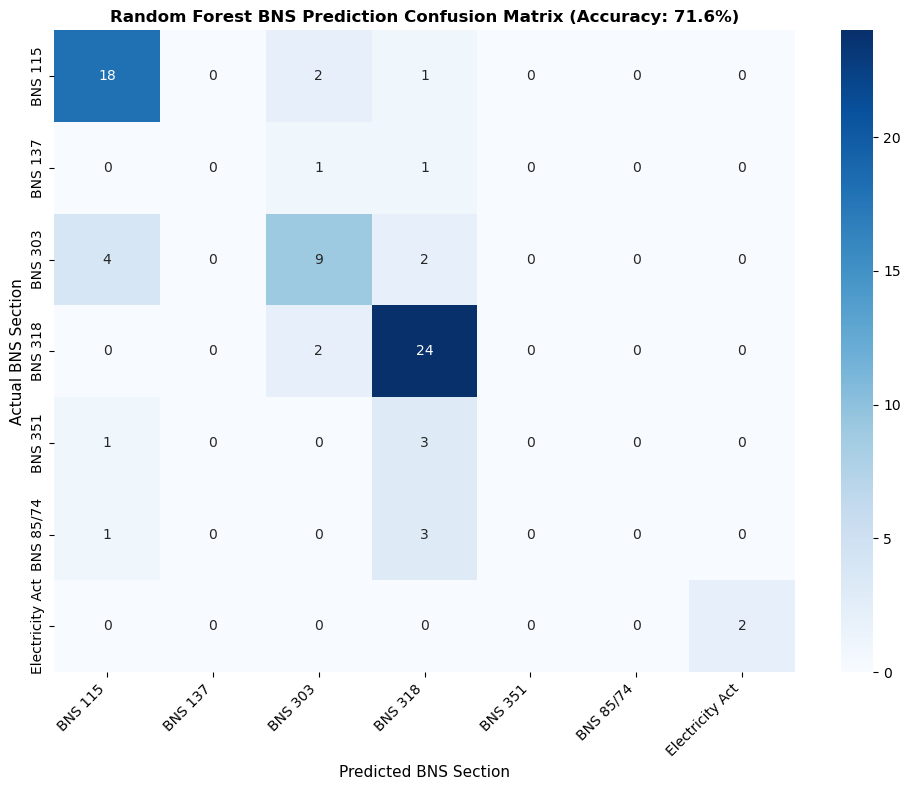

📈 Confusion Matrix chart saved: 'bns_confusion_matrix.png'


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load Master Dataset
print("📥 Loading dataset...")
with open("master_fir_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# 2. Map Categories to BNS
def map_to_bns(category):
    cat = str(category).lower()
    if any(k in cat for k in ['theft', 'snatching', 'burglary', 'pickpocket', '379', '380', '399', '402']):
        return 'BNS 303 (Theft & Snatching)'
    elif any(k in cat for k in ['fraud', 'cyber', 'cheating', 'forgery', '420', '406']):
        return 'BNS 318 (Cheating & Financial Fraud)'
    elif any(k in cat for k in ['assault', 'violence', 'hurt', '323', '325', '341']):
        return 'BNS 115 (Voluntarily Causing Hurt)'
    elif any(k in cat for k in ['threat', 'intimidation', 'extortion', '506', '384']):
        return 'BNS 351 (Criminal Intimidation)'
    elif any(k in cat for k in ['dowry', 'domestic', 'harassment', '498a', '354']):
        return 'BNS 85/74 (Offenses Against Women)'
    elif any(k in cat for k in ['kidnap', 'abduction', '363', '365']):
        return 'BNS 137 (Kidnapping & Abduction)'
    elif any(k in cat for k in ['electricity', '135']):
        return 'Electricity Act Section 135'
    else:
        return 'BNS General / Other Sections'

df['bns_section'] = df['crime_category'].apply(map_to_bns)
clean_df = df[df['bns_section'] != 'BNS General / Other Sections'].copy()

X = clean_df['summary']
y = clean_df['bns_section']

# 3. Load Trained Model & Vectorizer
print("🤖 Loading trained Random Forest model and vectorizer...")
model = joblib.load("rf_bns_model.joblib")
vectorizer = joblib.load("tfidf_vectorizer.joblib")

# 4. Split and Transform Test Set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test_vec = vectorizer.transform(X_test)

# 5. Predict on Test Set
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f"\n🎯 Overall Test Accuracy: {acc * 100:.2f}%\n")

# 6. Generate & Save Classification Report
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("bns_classification_report.csv")
print("💾 Classification report saved: 'bns_classification_report.csv'")
print("\nDetailed Report:\n", classification_report(y_test, y_pred, zero_division=0))

# 7. Plot & Save Confusion Matrix
labels = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[l.split(' ')[0] + ' ' + l.split(' ')[1] for l in labels],
            yticklabels=[l.split(' ')[0] + ' ' + l.split(' ')[1] for l in labels])
plt.title(f'Random Forest BNS Prediction Confusion Matrix (Accuracy: {acc*100:.1f}%)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted BNS Section', fontsize=11)
plt.ylabel('Actual BNS Section', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("bns_confusion_matrix.png", dpi=300)
plt.show()

print("📈 Confusion Matrix chart saved: 'bns_confusion_matrix.png'")